In [11]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("../")))

import numpy as np
from src.utilities import ricker_wavelet, green2d, low_freq_taper
from src.plot.plot_tools import plot_signal_time_freq

This is a toy notebook to set up the parameters for the time to frequency domain transformations.

We generate a seismic source in time, and convert it into the frequency domain using fft. 
Suppose the source is a standard ricker wavelet. We specify the total simulation time and the central frequency in Hz.

In [12]:
total_time = 1.2    # simulation time [sec]
f0 = 8.0  # Ricker central frequency (Hz)

By fixing the time-resolution for the maximum frequency, we define all the parameters for the frequency domain fft.

In [13]:
f_max = 4.0 * f0    # Ricker max-frequency for cutoff
f_min = 0.1 # minimum frequency
# set approx. Nyquist frequency for f_max
dt = 1/(2.5*f_max) # minimum dt

# time array
nt = int(total_time / dt) + 1
time = np.arange(nt) * dt
# zero-pad to the next power of 2 for fft
nfft = 2**int(np.ceil(np.log2(nt)))
# to prevent wrap-around we can again multiply nfft by 2

time step dt =  0.0125 [sec]
number of time points nt = 96
number of fft points (power of two), nfft = 128


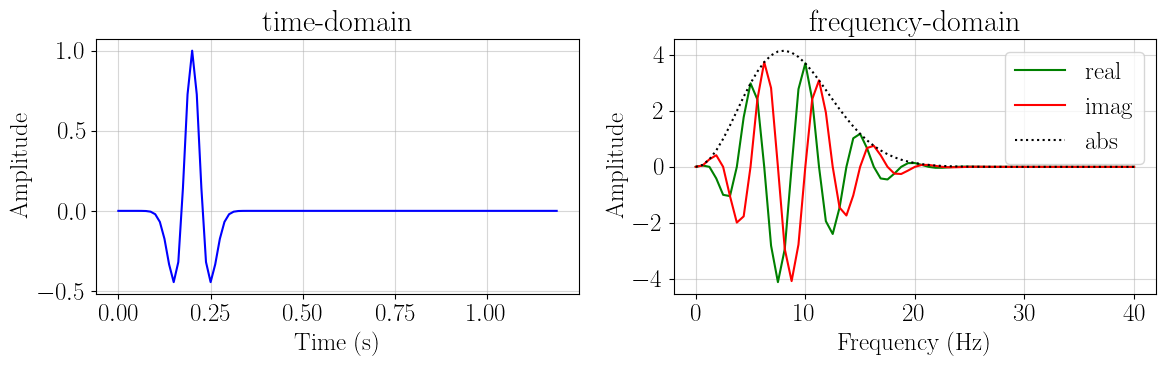

In [14]:
print("time step dt = ", dt, "[sec]")
print("number of time points nt =", nt)
print("number of fft points (power of two), nfft =", nfft)

s_t, delay = ricker_wavelet(time, f0)
# we use the -i*w*t convention for the FFT (physics convention), while numpy use +i*w*t by default
s_w = np.conj(np.fft.rfft(s_t, n=nfft))
freqs = np.fft.rfftfreq(nfft, dt)
omega = 2.*np.pi*freqs

plot_signal_time_freq(time, s_t, freqs, s_w)

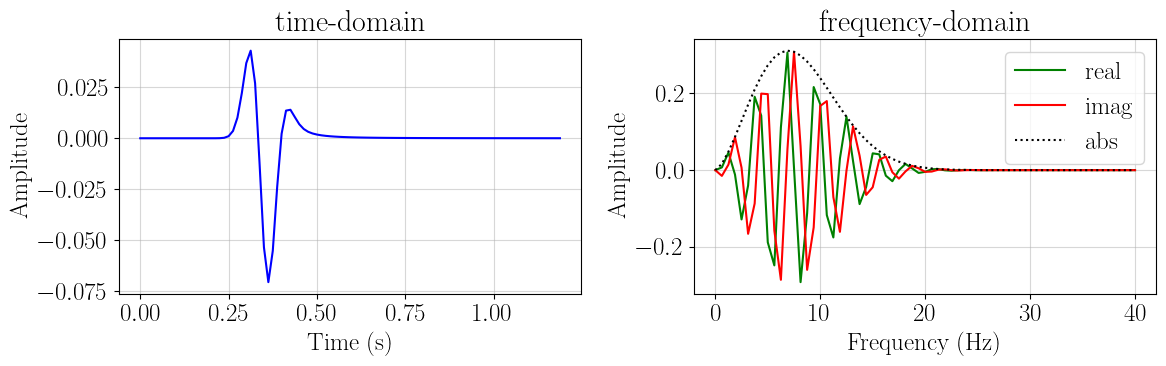

In [15]:
# multiply the source by a signal and do inverse FFT
G = green2d(omega, c=2000., distances=300.)
# convolution = multiplication in the frequency domain
signal_w = G.flatten()*s_w
# filter low-frequencies below f_min
signal_w *= low_freq_taper(omega, omega_min=2*np.pi*f_min)
# inverse FFT
signal_time = np.conj(np.fft.irfft(np.conj(signal_w), n=nfft))
# truncate to the number of time points
signal_time = signal_time[:nt]

plot_signal_time_freq(time, signal_time, freqs, signal_w)

We obtain the time-domain response at a receiver located at 300m from the source in a homogeneous medium.  
We can now use this workflow to convolve the source with more advanced frequency-domain signals.